이상 데이터 추출

In [57]:
import pandas as pd
import numpy as np

In [58]:
df_test = pd.read_csv('test_features.csv')
df_train = pd.read_csv('train_features.csv')
df_valid = pd.read_csv('valid_features.csv')

In [59]:
#3개의 df 각각 전처리

feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

# 1. inf 값을 NaN으로 바꾸기
df_test = df_test.replace([np.inf, -np.inf], np.nan)
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_valid = df_valid.replace([np.inf, -np.inf], np.nan)

# 2. feature 컬럼 기준 결측치 제거
df_test = df_test.dropna(subset=feature_cols).copy()
df_train = df_train.dropna(subset=feature_cols).copy()
df_valid = df_valid.dropna(subset=feature_cols).copy()

# 3. 너무 큰 값 잘라내기: 극단값 완화
for col in feature_cols:
    lower = df_test[col].quantile(0.01)
    upper = df_test[col].quantile(0.99)
    df_test[col] = df_test[col].clip(lower, upper)
    lower = df_train[col].quantile(0.01)
    upper = df_train[col].quantile(0.99)
    df_train[col] = df_train[col].clip(lower, upper)
    lower = df_valid[col].quantile(0.01)
    upper = df_valid[col].quantile(0.99)
    df_valid[col] = df_valid[col].clip(lower, upper)

# 4. X 생성
X_test = df_test[feature_cols].copy()
X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
print("test dataset 전처리 완료 및 크기")
print(X_test.isna().sum())
print(np.isinf(X_test).sum())
print(X_test.shape)
print("train dataset 전처리 완료 및 크기")
print(X_train.isna().sum())
print(np.isinf(X_train).sum())
print(X_train.shape)
print("validation dataset 전처리 완료 및 크기")
print(X_valid.isna().sum())
print(np.isinf(X_valid).sum())
print(X_valid.shape)

test dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
(3698, 8)
train dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtyp

In [60]:
#df_scaled에 date부터 group까지의 데이터를 보존하기 위해 미리 합친 df를 복사해두고 스케일링 대상 변수에 스케일링 후 값을 대입했습니다.
df = pd.concat([df_test, df_train, df_valid], ignore_index=True)
df_scaled = df.copy()

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_train[feature_cols])
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

df_scaled.head()

,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,2026-03-25,16660.0,16660.0,16750.0,16600.0,16700.0,110810.0,000080.KS,Medium,-0.289572,-0.675238,-0.043488,-0.243230,-0.864405,0.216924,-0.384538,0.534481
1,2026-03-26,16540.0,16540.0,16780.0,16430.0,16780.0,118977.0,000080.KS,Medium,-0.140895,-0.613357,-0.307616,-0.423872,-0.693248,-1.240012,0.212655,0.534481
2,2026-03-27,16730.0,16730.0,16740.0,16330.0,16510.0,132871.0,000080.KS,Medium,-0.095828,-0.493258,0.440014,-0.366307,-0.992688,-1.133407,0.000128,-0.424950
3,2026-03-30,16470.0,16470.0,16700.0,16350.0,16430.0,83695.0,000080.KS,Medium,-0.605205,-0.798315,-0.641148,-0.434862,-0.621405,1.632233,-0.601699,-0.424950
4,2026-03-31,16720.0,16720.0,17090.0,16400.0,16410.0,276697.0,000080.KS,Medium,2.194555,0.537544,0.587691,-0.590948,-0.545309,1.103755,-0.124299,0.534481


In [62]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(X_train_scaled)

#이상치 점수
df_scaled["anomaly_score"] = -iso_model.decision_function(X_scaled)
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df_scaled["anomaly_label"] = iso_model.predict(X_scaled)
df_scaled["anomaly_label"] = df_scaled["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df_scaled["anomaly_label"].value_counts()

anomaly_label
0    48191
1     1540
Name: count, dtype: int64

In [63]:
df_scaled.head()

,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d,anomaly_score,anomaly_label
0,2026-03-25,16660.0,16660.0,16750.0,16600.0,16700.0,110810.0,000080.KS,Medium,-0.289572,-0.675238,-0.043488,-0.243230,-0.864405,0.216924,-0.384538,0.534481,-0.210796,0
1,2026-03-26,16540.0,16540.0,16780.0,16430.0,16780.0,118977.0,000080.KS,Medium,-0.140895,-0.613357,-0.307616,-0.423872,-0.693248,-1.240012,0.212655,0.534481,-0.218972,0
2,2026-03-27,16730.0,16730.0,16740.0,16330.0,16510.0,132871.0,000080.KS,Medium,-0.095828,-0.493258,0.440014,-0.366307,-0.992688,-1.133407,0.000128,-0.424950,-0.154985,0
3,2026-03-30,16470.0,16470.0,16700.0,16350.0,16430.0,83695.0,000080.KS,Medium,-0.605205,-0.798315,-0.641148,-0.434862,-0.621405,1.632233,-0.601699,-0.424950,-0.218104,0
4,2026-03-31,16720.0,16720.0,17090.0,16400.0,16410.0,276697.0,000080.KS,Medium,2.194555,0.537544,0.587691,-0.590948,-0.545309,1.103755,-0.124299,0.534481,-0.178792,0


In [64]:
#이상치 점수가 가장 높은 30개의 데이터 확인
top_anomaly = (
    df_scaled
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

top_anomaly[[
    "date",
    "ticker",
    "anomaly_score",
    "vol_chg_rate",
    "volume_ma20_ratio",
    "volatility_5d",
    "upper_shadow_ratio"
]]

,date,ticker,anomaly_score,vol_chg_rate,volume_ma20_ratio,volatility_5d,upper_shadow_ratio
18377,2024-06-13,011170.KS,0.144644,0.645417,0.768373,1.958343,-1.047182
18519,2025-01-13,011170.KS,0.131762,-0.061314,0.050737,-0.556794,0.045520
44512,2025-04-10,192820.KS,0.130960,-0.538225,0.671305,1.593505,-0.754366
34094,2025-05-26,051900.KS,0.129489,-0.415150,-0.232068,-0.620897,-0.319842
33546,2025-01-06,047040.KS,0.126843,-0.289407,-0.313809,0.056578,-0.365850
37717,2025-05-27,060230.KQ,0.126761,-0.505110,-0.056170,0.713430,1.026333
33964,2024-11-08,051900.KS,0.123965,-0.102489,-0.270141,-0.751309,0.216924
37711,2025-05-19,060230.KQ,0.121247,-0.457156,-0.724391,2.712309,-0.099801
18523,2025-01-17,011170.KS,0.118591,-0.528348,-0.567934,-0.463659,2.038094
37750,2025-07-15,060230.KQ,0.118504,-0.485841,-0.839731,-0.348968,-1.240012


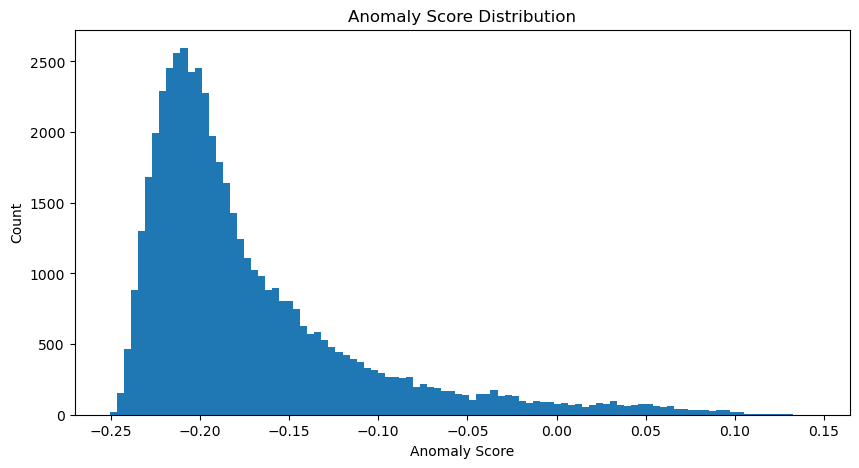

In [66]:
#이상치 점수 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_scaled["anomaly_score"], bins=100)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.savefig('Anomaly Score Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

이상 데이터 분리 후 클러스터링

In [67]:
#이상 데이터만 따로 분류
anomaly_df = df_scaled[
    df_scaled["anomaly_label"] == 1
].copy()

In [68]:
#클러스터링에 사용할 feature들

cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_cluster = anomaly_df[cluster_feature_cols].copy()

#클러스터링 전 전처리: 무한대 값 및 결측치 포함된 행 제거
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.dropna()

# anomaly_df도 X_cluster 인덱스에 맞추기
anomaly_df = anomaly_df.loc[X_cluster.index].copy()

print(X_cluster.shape)

(1540, 8)


C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

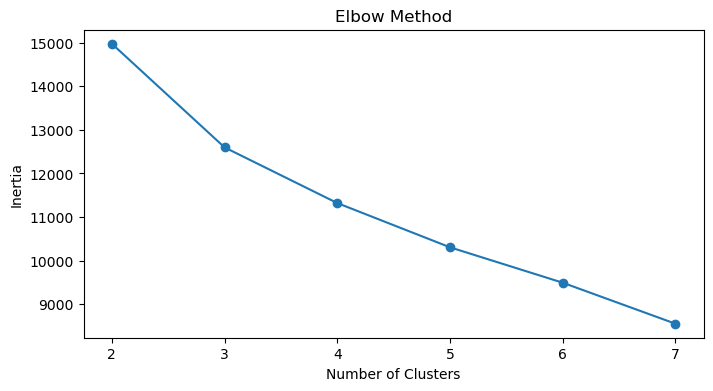

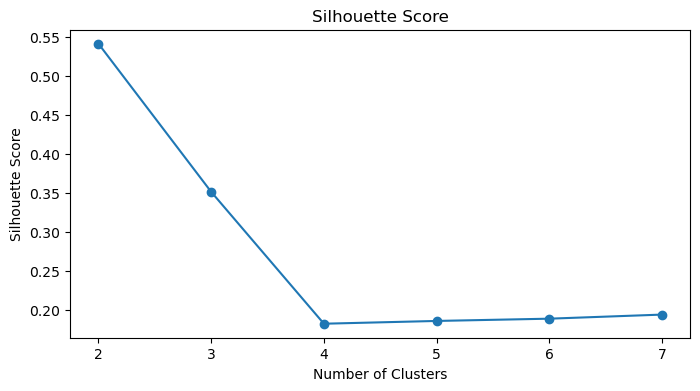

,k,inertia,silhouette
0,2,14973.991130,0.541532
1,3,12598.025999,0.351426
2,4,11321.688205,0.182171
3,5,10307.810443,0.185735
4,6,9496.150587,0.188646
5,7,8556.427696,0.193894


In [69]:
#K-Means 수행 전 K 설정 위한 inertia, silhouette score 확인
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig('Elbow Method.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.savefig('Silhouette .png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [70]:
#k=3 에서 높은 실루엣 점수가 나타났으니 k=3으로 설정 후 K-Means 진행

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
anomaly_df["cluster"] = kmeans.fit_predict(X_cluster)

anomaly_df["cluster"].value_counts().sort_index()

C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


cluster
0     238
1     135
2    1167
Name: count, dtype: int64

In [71]:
#클러스터 별 feature 평균값 확인
cluster_profile = (
    anomaly_df
    .groupby("cluster")[cluster_feature_cols]
    .mean()
)

cluster_profile

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,-0.053547,0.096329,-1.043722,1.997686,2.219835,-0.166944,0.332868,-0.054078
1,3.492759,4.631318,2.795038,2.323352,0.328044,0.061485,0.084644,-0.154888
2,-0.080512,-0.166656,0.076593,-0.231090,-0.202740,-0.017812,-0.098670,-0.013883


In [72]:
#평균값 표준화 시킨 후 재확인
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

cluster_profile_scaled = pd.DataFrame(
    cluster_scaler.transform(cluster_profile),
    columns=cluster_feature_cols,
    index=cluster_profile.index
)

cluster_profile_scaled

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,-0.203456,-0.121425,-0.821478,1.061501,1.645623,-0.126401,0.392999,-0.021139
1,2.280733,2.656052,1.838588,1.269701,0.090316,0.090637,0.113301,-0.119699
2,-0.222345,-0.282492,-0.045157,-0.363365,-0.346059,0.015294,-0.093256,0.018158


In [73]:
#클러스터별 주요 특징
for cluster_id in sorted(anomaly_df["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} 주요 특징 =====")

    row = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    print(row.head(5))


===== Cluster 0 주요 특징 =====
drawdown_after_peak_5d    1.645623
volatility_5d             1.061501
body_ratio                0.392999
upper_shadow_streak_5d   -0.021139
volume_ma20_ratio        -0.121425
Name: 0, dtype: float64

===== Cluster 1 주요 특징 =====
volume_ma20_ratio    2.656052
vol_chg_rate         2.280733
daily_return         1.838588
volatility_5d        1.269701
body_ratio           0.113301
Name: 1, dtype: float64

===== Cluster 2 주요 특징 =====
upper_shadow_streak_5d    0.018158
upper_shadow_ratio        0.015294
daily_return             -0.045157
body_ratio               -0.093256
vol_chg_rate             -0.222345
Name: 2, dtype: float64


In [74]:
anomaly_df.to_csv("anomaly_cluster_result.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile_raw.csv", encoding="utf-8-sig")
cluster_profile_scaled.to_csv("cluster_profile_scaled.csv", encoding="utf-8-sig")